In [ ]:
from nconpp import Graph

g = Graph(5, False)
print(g.num_vertices)
print(g.get_vertices())
print(g.vertices[0].edge_indices)
print(g.remove_vertex(0))
print(g.get_vertices())
print(g.add_vertex(5))
print(g.get_vertices())
print(g.add_edge(0,1,2))
print(g.add_edge(1,1,2))
print(g.get_edges())
print(g.num_edges)
print(g.edges[0].src, g.edges[0].dest)
print(g.remove_edge(0))
print(g.num_edges)
print(g.get_edges())

In [ ]:
from nconpp import LatticeGraph

# lg = LatticeGraph("honeycomb", [4,4], [((0, -1), (0, +1), (+1, 0)), ((-1, 0), (0, -1), (0, +1))], ("pbc", "pbc"))
lg = LatticeGraph()

print(lg.getGridShape())
print(lg.getBoundaryGridShape())
print(lg.getDirections())
print(lg.vertices[5].coordinate)

In [ ]:
import numpy as np
from nconpp import TensorNetwork

tensorList = [
    (np.random.randn(60)+1j*np.random.randn(60)).reshape(3,4,5),
    (np.random.randn(3780)+1j*np.random.randn(3780)).reshape(5, 3, 6, 7, 6),
    (np.random.randn(14)+1j*np.random.randn(14)).reshape(7,2),
    (np.random.randn(8)+1j*np.random.randn(8)).reshape(8),
    (np.random.randn(72)+1j*np.random.randn(72)).reshape(8,9),
    (np.random.randn(81)+1j*np.random.randn(81)).reshape(9,9)
]

legsList = [
    [3, -2, 2],
    [2, 3, 1, 4, 1],
    [4, -1],
    [5],
    [5, -3],
    [6, 6]
]

tn = TensorNetwork(tensorList, legsList)

print(tn.num_tensors)
tn.contract()
print(tn.num_tensors)
tn.connect()
print(tn.num_tensors)

12 36
((4, 4), (4, 1))
((4, 4), (1, 4))
((2, 4), (2, 1))
((1, 2), (4, 2))
((3, 4), (3, 1))
((2, 1), (2, 4))
((3, 1), (3, 4))
((4, 1), (4, 4))
((1, 1), (1, 4))
((4, 2), (1, 2))
((1, 4), (4, 4))
((1, 4), (1, 1))


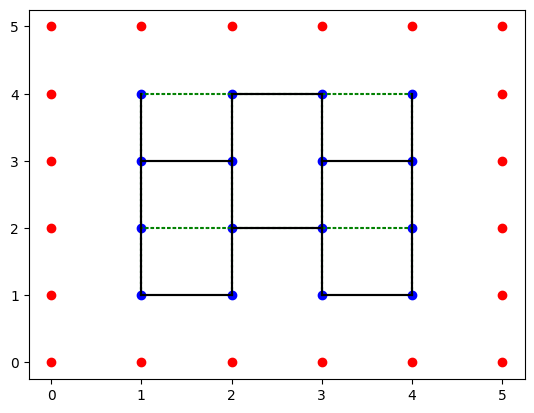

In [2]:
import numpy as np
import matplotlib.pyplot as plt

grid = (4, 4)
boundary_grid = list(np.add(grid, 2))
connectors = [((0, -1), (0, +1), (+1, 0)), ((-1, 0), (0, -1), (0, +1))]
number_of_sites = np.prod(grid)
boundary_conditions = ("pbc", "pbc")
boundary_points = set()
bulk_points = set()
coordinates = set()
edges = []
boundary_edges = []

sites_dict = {}

# start enumeration of edges
edge_index = 0

# iterate over all sites to unravel them to coordinates
for i in range(np.prod(boundary_grid)):  # i = 0, 1, 2, ...
    # unravel the index to get its coordinate representation
    origin = np.unravel_index(i, boundary_grid)  # e.g. d=2: ni = (0,0), ...

    coordinates.add(origin)

    for i, c in enumerate(origin):
        if c == 0 or c == boundary_grid[i] - 1:
            boundary_points.add(origin)

# retrieve the bulk points
bulk_points = coordinates - boundary_points

# now the connections
for origin in bulk_points:
    # iterate over all accumulators corresponding to site in unit cell
    for accu in connectors[sum(origin) % len(connectors)]:
        # retrieve the target site in coordinate representation
        target = np.add(origin, accu)

        if tuple(target) in bulk_points:
            edges.append((origin, tuple(target)))
        elif tuple(target) in boundary_points:
            for i, bc in enumerate(boundary_conditions):
                if bc == "obc":
                    pass
                elif bc == "pbc":
                    if target[i] == 0:
                        target[i] = grid[i]
                    elif target[i] == boundary_grid[i] - 1:
                        target[i] = 1
            boundary_edges.append((origin, tuple(target)))

# plot
fig, ax = plt.figure(), plt.axes()

# vertices
xb, yb = np.array(list(bulk_points)).T
ax.scatter(xb, yb, c="b")

xe, ye = np.array(list(boundary_points)).T
ax.scatter(xe, ye, c="r")

# edges
for e in boundary_edges:
    x, y = np.array(e).T
    ax.plot(x, y, c="g", linestyle=":")

for e in edges:
    x, y = np.array(e).T
    ax.plot(x, y, c="k", linestyle="-")
    
print(len(boundary_edges), len(edges))
for i in boundary_edges:
    print(i)

plt.show()

[4, 4]
[6, 6]
[[[0, -1], [0, 1], [1, 0]], [[-1, 0], [0, -1], [0, 1]]]


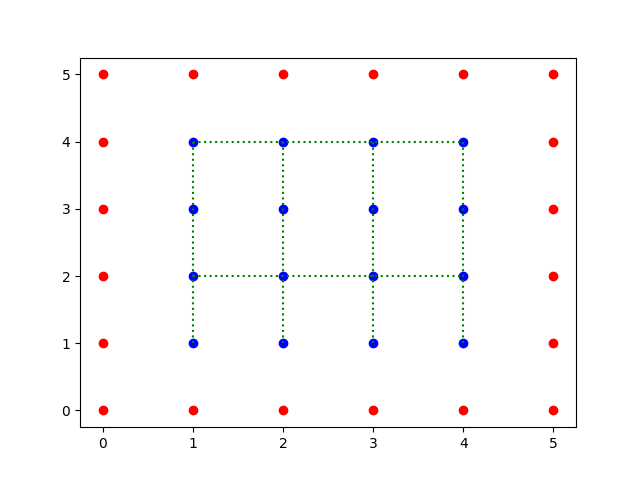

In [1]:
%matplotlib widget
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np

from nconpp import LatticeGraph

# lg = LatticeGraph("honeycomb", [4,4], [((0, -1), (0, +1), (+1, 0)), ((-1, 0), (0, -1), (0, +1))], ("pbc", "pbc"))
lg = LatticeGraph()

print(lg.getGridShape())
print(lg.getBoundaryGridShape())
print(lg.getDirections())

# plot
fig, ax = plt.figure(), plt.axes()

# vertices
for i in lg.vertices:
    v = lg.vertices[i]
    if v.boundary:
        ax.scatter(v.coordinate[0], v.coordinate[1], c="r")
    else:
        ax.scatter(v.coordinate[0], v.coordinate[1], c="b")
        
# edges
for i in lg.edges:
    e = lg.edges[i]
    e_src = lg.vertices[e.src].coordinate
    e_dest = lg.vertices[e.dest].coordinate
    x, y = np.array([e_src, e_dest]).T
    if (e.boundary):
        ax.plot(x, y, c="g", linestyle=":")
    else:
        ax.plot(x, y, c="k", linestyle="-")

plt.show()

In [ ]:
from matplotlib import pyplot as plt
from functools import partial
from ipywidgets import interact

import numpy as np

def f(x): return 3*x**2 + 2*x + 1

def plot_function(f, title=None, min=-2.1, max=2.1, color='r', ylim=None):
    x = np.linspace(min,max, 100)[:,None]
    if ylim: plt.ylim(ylim)
    plt.plot(x, f(x), color)
    if title is not None: plt.title(title)

def quad(a,b,c,x):
    return a*x**2 + b*x + c

def mk_quad(a,b,c): return partial(quad, a,b,c)
def noise(x, scale): return np.random.normal(scale=scale, size=x.shape)
def add_noise(x, mult, add): return x * (1+noise(x,mult)) + noise(x,add)

np.random.seed(42)

x = np.linspace(-2, 2)[:,None]
y = add_noise(f(x), 0.15, 1.5)

@interact(a=1.5, b = 1.5, c =1.5)
def plot_quad(a,b,c):
    plt.scatter(x,y)
    plot_function(mk_quad(a,b,c), ylim=(-3, 12))